In [47]:
#IMPORTANDO TOOLS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk

In [48]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

In [ ]:
from data_loading import load_data

df = load_data()

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Columns: 403 entries, 0.a_token to 8.d.12_Treinando e aplicando LLM's para solucionar problemas de negócio.
dtypes: bool(1), float64(323), int64(1), object(5), str(73)
memory usage: 16.0+ MB


In [51]:
df.columns

Index(['0.a_token', '0.d_data/hora_envio', '1.a_idade', '1.a.1_faixa_idade',
       '1.b_genero', '1.c_cor/raca/etnia', '1.d_pcd',
       '1.e_experiencia_profissional_prejudicada',
       '1.e.1_Não acredito que minha experiência profissional seja afetada',
       '1.e.2_Sim, devido a minha Cor/Raça/Etnia',
       ...
       '8.d.3_Entrando em contato com os times de negócio para definição do problema, identificar a solução e apresentação de resultados.',
       '8.d.4_Desenvolvendo modelos de Machine Learning com o objetivo de colocar em produção em sistemas (produtos de dados).',
       '8.d.5_Colocando modelos em produção, criando os pipelines de dados, APIs de consumo e monitoramento.',
       '8.d.6_Cuidando da manutenção de modelos de Machine Learning já em produção, atuando no monitoramento, ajustes e refatoração quando necessário.',
       '8.d.7_Realizando construções de dashboards em ferramentas de BI como PowerBI, Tableau, Looker, Qlik, etc.',
       '8.d.8_Utilizando ferra

In [52]:
#Selecionando o target
list(df.columns)
df['2.h_faixa_salarial'].value_counts().sort_values()

2.h_faixa_salarial
Menos de R$ 1.000/mês                 33
Acima de R$ 40.001/mês               104
de R$ 1.001/mês a R$ 2.000/mês       155
de R$ 30.001/mês a R$ 40.000/mês     158
de R$ 25.001/mês a R$ 30.000/mês     159
de R$ 2.001/mês a R$ 3.000/mês       237
de R$ 20.001/mês a R$ 25.000/mês     246
de R$ 3.001/mês a R$ 4.000/mês       270
de R$ 16.001/mês a R$ 20.000/mês     456
de R$ 4.001/mês a R$ 6.000/mês       593
de R$ 6.001/mês a R$ 8.000/mês       656
de R$ 12.001/mês a R$ 16.000/mês     716
de R$ 8.001/mês a R$ 12.000/mês     1080
Name: count, dtype: int64

In [53]:
#Removendo os NANs e agrupando as 13 categorias em 6 maiores
novas_categorias = {
    'de R$ 8.001/mês a R$ 12.000/mês': 'de R$ 8.001/mês a R$ 12.000/mês',
    'de R$ 12.001/mês a R$ 16.000/mês': 'de R$ 12.001/mês a R$ 20.000/mês',
    'de R$ 6.001/mês a R$ 8.000/mês': 'de R$ 6.001/mês a R$ 8.000/mês',
    'de R$ 4.001/mês a R$ 6.000/mês': 'de 3.001/mês a R$ 6.000/mês',
    'de R$ 16.001/mês a R$ 20.000/mês': 'de R$ 12.001/mês a R$ 20.000/mês',
    'de R$ 3.001/mês a R$ 4.000/mês': 'de 3.001/mês a R$ 6.000/mês',
    'de R$ 20.001/mês a R$ 25.000/mês': 'acima de R$ 20.000/mês',
    'de R$ 2.001/mês a R$ 3.000/mês': 'até R$ 3.000/mês',
    'de R$ 25.001/mês a R$ 30.000/mês': 'acima de R$ 20.000/mês',
    'de R$ 30.001/mês a R$ 40.000/mês': 'acima de R$ 20.000/mês',
    'de R$ 1.001/mês a R$ 2.000/mês': 'até R$ 3.000/mês',
    'Acima de R$ 40.001/mês': 'acima de R$ 20.000/mês',
    'Menos de R$ 1.000/mês': 'até R$ 3.000/mês'
}

df['categorias_target'] = df['2.h_faixa_salarial'].map(novas_categorias)

C:\Users\Ian Guilherme Dev\AppData\Local\Temp\ipykernel_2860\1397525378.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['categorias_target'] = df['2.h_faixa_salarial'].map(novas_categorias)


<Axes: >

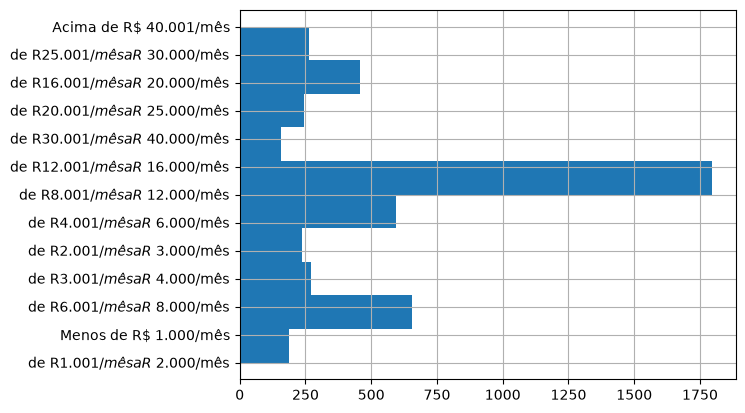

In [54]:

df['2.h_faixa_salarial'].hist(orientation='horizontal',
                              histtype='bar')

In [55]:
#correcting the order of the targets
from pandas import CategoricalDtype
categorias = CategoricalDtype(categories=[
    'até R$ 3.000/mês',           
    'de 3.001/mês a R$ 6.000/mês',      
    'de R$ 6.001/mês a R$ 8.000/mês',      
    'de R$ 8.001/mês a R$ 12.000/mês',     
    'de R$ 12.001/mês a R$ 20.000/mês',    
    'acima de R$ 20.000/mês'      
], ordered=True)

df['categorias_target'] = df['categorias_target'].astype(categorias)



<Axes: ylabel='categorias_target'>

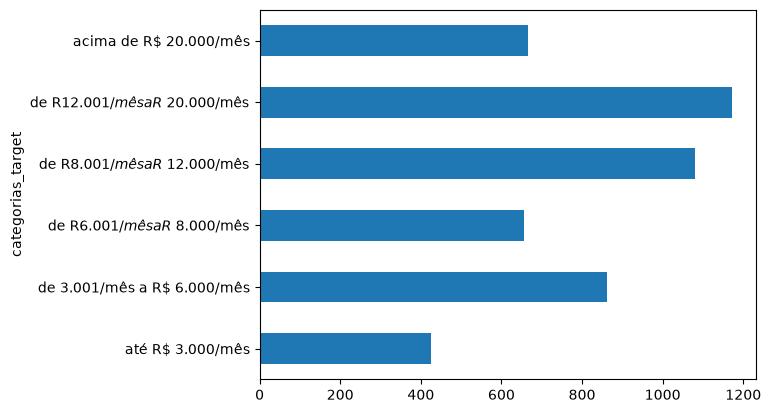

In [56]:
df['categorias_target'].value_counts().sort_index().plot(kind='barh', )

In [57]:
#rapida limpeza no df
remover = ['Vivo fora do Brasil e trabalho para empresa de fora do Brasil',
                          'Desempregado e não estou buscando recolocação']

df = df[~df['2.a_situação_de_trabalho'].isin(remover)]
df = df[df['categorias_target'].notna()]

Removendo linhas com vive_em_brasil == False, pois quero centralizar essa pesquisa para pessoas que moram no território brasileiro e ao analisar a coluna '1.h_pais_onde_mora', percebi que os dados não iriam auxiliar no projeto. Além de que a mudança na forma de pagamento pode tornar o projeto tendencioso.

In [58]:
df = df[df['1.g_vive_no_brasil']] 

In [59]:
teste_filtro_por_linguagem = [ 
    '4.d.1_SQL',
    '4.d.2_R',
    '4.d.3_Python',
    '4.d.4_C/C++/C#',
    '4.d.5_.NET',
    '4.d.6_Java',
    '4.d.7_Julia',
    '4.d.12_Rust',
    '4.d.13_PHP',
    '4.d.14_JavaScript',
    '4.d.15_Não utilizo nenhuma das linguagens listadas'
]

df[teste_filtro_por_linguagem].dropna().sum().sort_values()


4.d.15_Não utilizo nenhuma das linguagens listadas       0.0
4.d.7_Julia                                              6.0
4.d.12_Rust                                             12.0
4.d.5_.NET                                              30.0
4.d.13_PHP                                              34.0
4.d.4_C/C++/C#                                          44.0
4.d.14_JavaScript                                      217.0
4.d.6_Java                                             278.0
4.d.2_R                                                342.0
4.d.3_Python                                          2856.0
4.d.1_SQL                                             3059.0
dtype: float64

<Axes: >

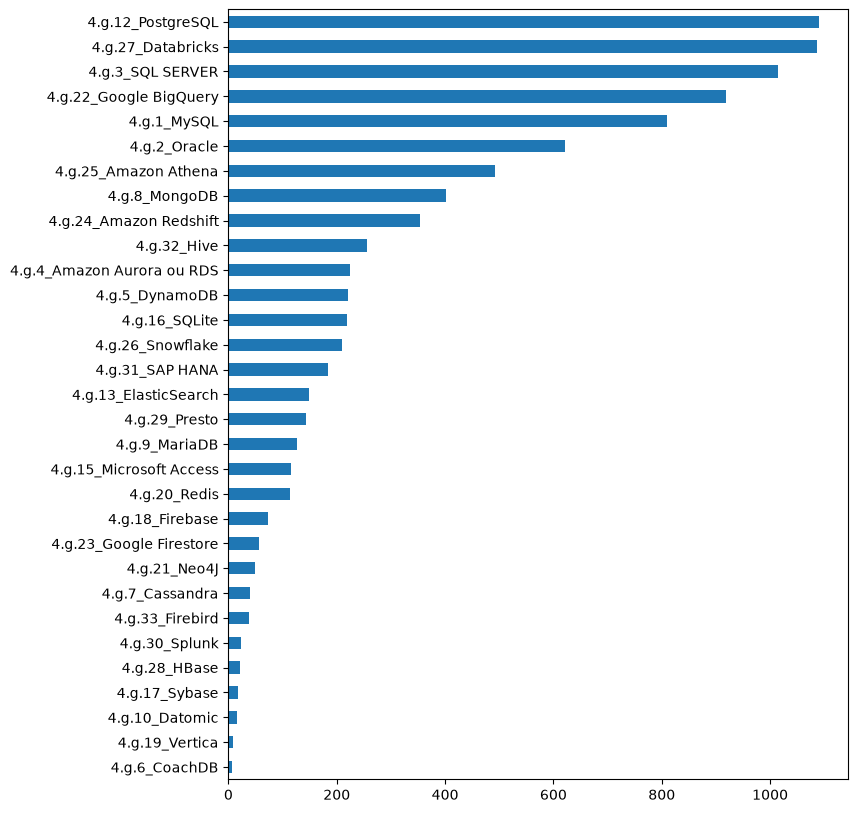

In [60]:
teste_filtro_por_db = [ 
'4.g.1_MySQL',
'4.g.2_Oracle',
'4.g.3_SQL SERVER',
'4.g.4_Amazon Aurora ou RDS',
'4.g.5_DynamoDB',
'4.g.6_CoachDB',
'4.g.7_Cassandra',
'4.g.8_MongoDB',
'4.g.9_MariaDB',
'4.g.10_Datomic',
'4.g.12_PostgreSQL',
'4.g.13_ElasticSearch',
'4.g.15_Microsoft Access',
'4.g.16_SQLite',
'4.g.17_Sybase',
'4.g.18_Firebase',
'4.g.19_Vertica',
'4.g.20_Redis',
'4.g.21_Neo4J',
'4.g.22_Google BigQuery',
'4.g.23_Google Firestore',
'4.g.24_Amazon Redshift',
'4.g.25_Amazon Athena',
'4.g.26_Snowflake',
'4.g.27_Databricks',
'4.g.28_HBase',
'4.g.29_Presto',
'4.g.30_Splunk',
'4.g.31_SAP HANA',
'4.g.32_Hive',
'4.g.33_Firebird',

]

df[teste_filtro_por_db].sum().sort_values(ascending=True).plot(kind="barh", figsize=(8, 10))


### banco de dados escolhidos 

O gráfico mostra que 6 bancos concentram a maioria do uso, com queda acentuada depois de Oracle — o que motiva o corte em top-6.

- 4.g.2_Oracle                   627.0
- 4.g.1_MySQL                    816.0
- 4.g.22_Google BigQuery         920.0
- 4.g.3_SQL SERVER              1022.0
- 4.g.27_Databricks             1089.0
- 4.g.12_PostgreSQL             1098.0

In [61]:
teste_filtro_por_cloud = [ 
'4.h.1_Amazon Web Services (AWS)',
'4.h.2_Google Cloud (GCP)',
'4.h.3_Azure (Microsoft)',
'4.h.4_Oracle Cloud',
'4.h.5_IBM',
'4.h.6_Servidores On Premise/Não utilizamos Cloud',
'4.h.7_Cloud Própria'
]

df[teste_filtro_por_cloud].sum().sort_values(ascending=True)


4.h.5_IBM                                             57.0
4.h.4_Oracle Cloud                                   137.0
4.h.7_Cloud Própria                                  184.0
4.h.6_Servidores On Premise/Não utilizamos Cloud     448.0
4.h.2_Google Cloud (GCP)                            1024.0
4.h.3_Azure (Microsoft)                             1067.0
4.h.1_Amazon Web Services (AWS)                     1543.0
dtype: float64

In [62]:
df['2.j_tempo_de_experiencia_em_ti'].value_counts().sort_index()

2.j_tempo_de_experiencia_em_ti
Mais de 10 anos                                                                                             379
Menos de 1 ano                                                                                              444
Não tive experiência na área de TI/Engenharia de Software antes de começar a trabalhar na área de dados    2572
de 1 a 2 anos                                                                                               533
de 3 a 4 anos                                                                                               377
de 5 a 6 anos                                                                                               213
de 7 a 10 anos                                                                                              204
Name: count, dtype: int64

_Na feature de situação de trabalho removi tanto a categoria de viver fora do Brasil ( pois o projeto tem enfoque no mercado de trabalho brasileiro ), quanto a de estar desemprehado e não buscando por realocação ( por não conter faixa salarial)_

In [63]:
df.to_csv('experiments_data/experiments_dataset.csv')